# The Case for a Central RSE Team

This notebook presents a longitudinal argument using the 2016, 2017, 2018, and 2022 RSE survey waves.

Narrative claim: institutions with a central or dedicated RSE team show stronger software resilience, measured through:
- transition planning when developers leave
- reduced single-point-of-failure risk (bus factor <= 1)


## Notebook structure

1. Load the prepared longitudinal outputs (or regenerate if missing)
2. Show sample context and comparability caveats
3. Quantify dedicated-group advantages year by year
4. Visualise the effect and interpret why central RSE teams matter for institutions


In [1]:
from pathlib import Path
import subprocess
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk", palette="colorblind")
pd.options.display.float_format = "{:,.2f}".format


In [2]:
# Resolve paths whether the notebook is run from repository root or from exeter_analysis/.
candidates = [Path.cwd(), Path.cwd() / "exeter_analysis"]
analysis_dir = next((d for d in candidates if (d / "rse_longitudinal_analysis.py").exists()), None)
if analysis_dir is None:
    raise FileNotFoundError("Could not locate exeter_analysis/rse_longitudinal_analysis.py")

repo_root = analysis_dir.parent / "RSE_survey_longitudinal"
output_dir = analysis_dir / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

required = ["yearly_summary.csv", "group_summary.csv", "effect_summary.csv"]
missing = [name for name in required if not (output_dir / name).exists()]

if missing:
    print(f"Missing outputs: {missing}. Regenerating now...")
    subprocess.check_call([
        sys.executable,
        str(analysis_dir / "rse_longitudinal_analysis.py"),
        "--repo-root", str(repo_root),
        "--output-dir", str(output_dir),
    ])

yearly = pd.read_csv(output_dir / "yearly_summary.csv")
group = pd.read_csv(output_dir / "group_summary.csv")
effect = pd.read_csv(output_dir / "effect_summary.csv")

print(f"Loaded yearly rows: {len(yearly)}")
print(f"Loaded group rows: {len(group)}")
print(f"Loaded effect rows: {len(effect)}")


Loaded yearly rows: 4
Loaded group rows: 8
Loaded effect rows: 4


## 1) Sample context and comparability

Before discussing institutional benefits, check context first. Coverage expands from one country (2016) to 41 countries (2022), so absolute percentages should be interpreted cautiously.

The key test is directional consistency: does dedicated-team membership repeatedly align with better resilience outcomes despite changing sample composition?


In [3]:
context_cols = [
    "survey_year",
    "n_respondents",
    "n_countries",
    "dedicated_group_yes_pct",
    "transition_plan_yes_pct",
    "bus_single_point_risk_pct",
]
display(yearly[context_cols])


,survey_year,n_respondents,n_countries,dedicated_group_yes_pct,transition_plan_yes_pct,bus_single_point_risk_pct
0,2016,273,1,60.07,21.61,45.76
1,2017,911,6,50.62,20.73,53.11
2,2018,956,32,50.12,18.19,56.71
3,2022,940,41,52.96,17.16,56.66


## 2) Dedicated-group advantage by year

Now isolate the core comparison: respondents in dedicated groups versus respondents outside dedicated groups.

Two effect sizes are used:
- transition advantage (Yes minus No)
- bus-risk reduction (No minus Yes)

Positive values in either metric support the central-team benefit hypothesis.


In [4]:
yes = group[group["group_label"] == "Dedicated group: Yes"].set_index("survey_year")
no = group[group["group_label"] == "Dedicated group: No"].set_index("survey_year")

comparison = pd.DataFrame(index=sorted(group["survey_year"].unique()))
comparison["n_yes"] = yes["n_respondents"]
comparison["n_no"] = no["n_respondents"]
comparison["transition_yes_pct"] = yes["transition_plan_yes_pct"]
comparison["transition_no_pct"] = no["transition_plan_yes_pct"]
comparison["bus_risk_yes_pct"] = yes["bus_single_point_risk_pct"]
comparison["bus_risk_no_pct"] = no["bus_single_point_risk_pct"]
comparison["transition_advantage_pp"] = (
    comparison["transition_yes_pct"] - comparison["transition_no_pct"]
)
comparison["bus_risk_reduction_pp"] = (
    comparison["bus_risk_no_pct"] - comparison["bus_risk_yes_pct"]
)
comparison["total_n"] = comparison["n_yes"] + comparison["n_no"]

simple_avg_transition = comparison["transition_advantage_pp"].mean()
simple_avg_bus = comparison["bus_risk_reduction_pp"].mean()
weighted_avg_transition = np.average(comparison["transition_advantage_pp"], weights=comparison["total_n"])
weighted_avg_bus = np.average(comparison["bus_risk_reduction_pp"], weights=comparison["total_n"])

print(f"Transition advantage (simple mean):  {simple_avg_transition:.2f} pp")
print(f"Transition advantage (weighted):     {weighted_avg_transition:.2f} pp")
print(f"Bus-risk reduction (simple mean):   {simple_avg_bus:.2f} pp")
print(f"Bus-risk reduction (weighted):      {weighted_avg_bus:.2f} pp")
print()
print("Directional consistency checks:")
print(f"All years transition advantage > 0: {(comparison['transition_advantage_pp'] > 0).all()}")
print(f"All years bus-risk reduction > 0:  {(comparison['bus_risk_reduction_pp'] > 0).all()}")

display(
    comparison[[
        "transition_yes_pct",
        "transition_no_pct",
        "transition_advantage_pp",
        "bus_risk_yes_pct",
        "bus_risk_no_pct",
        "bus_risk_reduction_pp",
    ]]
)


Transition advantage (simple mean):  8.65 pp
Transition advantage (weighted):     7.12 pp
Bus-risk reduction (simple mean):   12.70 pp
Bus-risk reduction (weighted):      12.97 pp

Directional consistency checks:
All years transition advantage > 0: True
All years bus-risk reduction > 0:  True


,transition_yes_pct,transition_no_pct,transition_advantage_pp,bus_risk_yes_pct,bus_risk_no_pct,bus_risk_reduction_pp
2016,28.66,11.01,17.65,42.59,50.46,7.87
2017,22.66,18.45,4.21,43.68,64.03,20.35
2018,21.53,14.85,6.68,50.58,63.01,12.43
2022,20.00,13.95,6.05,51.90,62.03,10.14


Interpretation: across all four waves, dedicated-group respondents report both better transition planning and lower single-point-failure risk.

This does not prove strict causality, but it gives a robust institutional signal: central team structures are repeatedly associated with operational resilience outcomes that matter to research continuity.


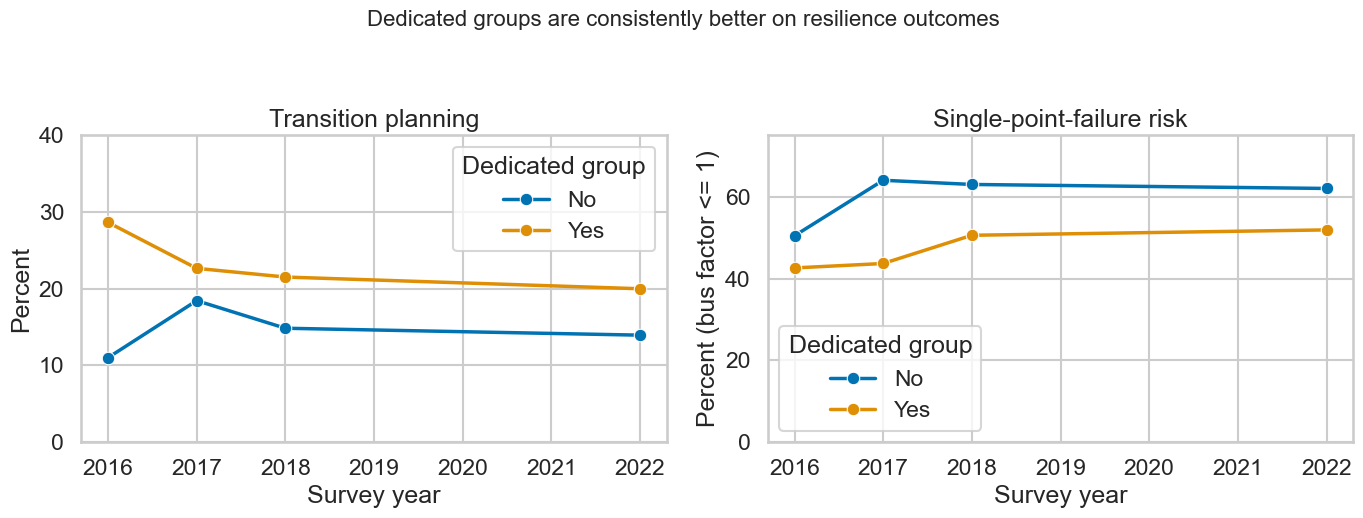

In [5]:
plot_df = group.copy()
plot_df["group"] = plot_df["group_label"].str.replace("Dedicated group: ", "", regex=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

sns.lineplot(
    data=plot_df,
    x="survey_year",
    y="transition_plan_yes_pct",
    hue="group",
    marker="o",
    linewidth=2.5,
    ax=axes[0],
)
axes[0].set_title("Transition planning")
axes[0].set_xlabel("Survey year")
axes[0].set_ylabel("Percent")
axes[0].set_ylim(0, 40)
axes[0].legend(title="Dedicated group")

sns.lineplot(
    data=plot_df,
    x="survey_year",
    y="bus_single_point_risk_pct",
    hue="group",
    marker="o",
    linewidth=2.5,
    ax=axes[1],
)
axes[1].set_title("Single-point-failure risk")
axes[1].set_xlabel("Survey year")
axes[1].set_ylabel("Percent (bus factor <= 1)")
axes[1].set_ylim(0, 75)
axes[1].legend(title="Dedicated group")

fig.suptitle("Dedicated groups are consistently better on resilience outcomes", y=1.05, fontsize=16)
fig.tight_layout()
plt.show()


## 3) Why central RSE teams likely produce this pattern

The metrics map to concrete organisational mechanisms:
- Central teams formalise handover practices, which increases transition-plan coverage
- They reduce knowledge silos through shared ownership, which lowers low-bus-factor risk
- They create continuity across projects when grant staffing or individual contracts change

In institutional terms, this is a shift from person-dependent software delivery to system-dependent software delivery.


In [6]:
# Relative-risk framing: values < 1 mean dedicated groups are safer on bus-factor risk.
rr = (comparison["bus_risk_yes_pct"] / comparison["bus_risk_no_pct"]).rename("bus_risk_relative_risk")
transition_ratio = (comparison["transition_yes_pct"] / comparison["transition_no_pct"]).rename("transition_ratio_yes_to_no")

ratio_table = pd.concat([rr, transition_ratio], axis=1)
display(ratio_table)

print(f"Mean bus-risk relative risk (Yes/No): {rr.mean():.2f}")
print(f"Mean transition ratio (Yes/No):       {transition_ratio.mean():.2f}")


,bus_risk_relative_risk,transition_ratio_yes_to_no
2016,0.84,2.60
2017,0.68,1.23
2018,0.80,1.45
2022,0.84,1.43


Mean bus-risk relative risk (Yes/No): 0.79
Mean transition ratio (Yes/No):       1.68


## Conclusion

Across all available waves, dedicated-group membership is associated with better resilience outcomes.

For university or institute leadership, the practical implication is straightforward: a central RSE team is not just a staffing preference, it is a resilience intervention.

Suggested institutional actions:
1. Establish or expand a central RSE function with explicit cross-project ownership expectations.
2. Track transition-plan coverage and low-bus-factor prevalence as annual service KPIs.
3. Pair growth in central RSE capacity with lightweight governance (handover templates, shared repos, cross-training).

Caveat: this is an observational association, not a randomised causal estimate. The consistent multi-year direction still makes it strong operational evidence for policy.
